# Chlorophyll vs CDOM 412 Scatterplot
Analyzing chlorophyll vs CDOM 412 for all years, colored by month and shaped by upwelling zone.

In [12]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [13]:
# Load the data
with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

lon_centers = np.array(metadata['lon_centers'])
lat_centers = np.array(metadata['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

In [14]:
# Define upwelling zone (example bounding box - adjust as needed)
upwelling_lon_min, upwelling_lon_max = -92.20216, -85.61256
upwelling_lat_min, upwelling_lat_max = 19.57871, 22.86906

is_upwelling = (lon_grid_2d >= upwelling_lon_min) & (lon_grid_2d <= upwelling_lon_max) & \
               (lat_grid_2d >= upwelling_lat_min) & (lat_grid_2d <= upwelling_lat_max)

In [15]:
# Process data for all years
results = []

for date_idx, row in df.iterrows():
    month = date_idx.month
    
    chlor = row.get('chlorophyll')
    cdom = row.get('cdom_412')
    
    if chlor is None or cdom is None:
        continue
    if isinstance(chlor, float) and np.isnan(chlor):
        continue
    if isinstance(cdom, float) and np.isnan(cdom):
        continue

    chlor_arr = np.array(chlor, dtype=float).flatten()
    cdom_arr = np.array(cdom, dtype=float).flatten()
    upwelling_arr = is_upwelling.flatten()
    
    # Valid mask
    valid = ~(np.isnan(chlor_arr) | np.isnan(cdom_arr))
    
    if not np.any(valid):
        continue
        
    chlor_valid = chlor_arr[valid]
    cdom_valid = cdom_arr[valid]
    upwelling_valid = upwelling_arr[valid]
    
    df_temp = pd.DataFrame({
        'chlor': chlor_valid,
        'cdom412': cdom_valid,
        'upwelling': upwelling_valid,
        'month': month
    })
    results.append(df_temp)

if len(results) == 0:
    print("No valid data points found! Check if 'chlorophyll' and 'cdom_412' are present and not all NaN.")
else:
    all_data = pd.concat(results, ignore_index=True)
    print(f"Total data points: {len(all_data)}")

Total data points: 35291388


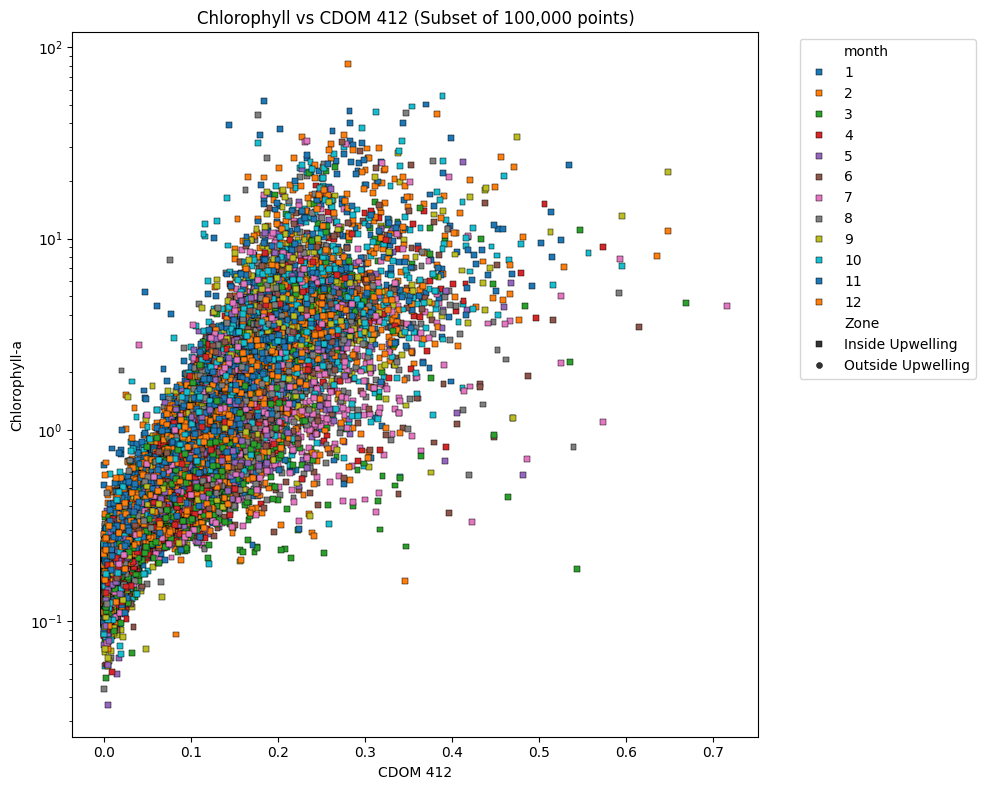

In [16]:
# Subset to 100,000 datapoints
if len(all_data) > 100000:
    sampled_data = all_data.sample(n=100000, random_state=42)
else:
    sampled_data = all_data.copy()

# Map upwelling boolean to descriptive string for legend
sampled_data['Zone'] = sampled_data['upwelling'].map({True: 'Inside Upwelling', False: 'Outside Upwelling'})

# Define marker shapes for each upwelling zone
zone_markers = {'Inside Upwelling': 's', 'Outside Upwelling': 'o'}

# Create scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=sampled_data, 
    x='cdom412', 
    y='chlor', 
    hue='month', 
    style='Zone', 
    style_order=['Inside Upwelling', 'Outside Upwelling'],
    markers=zone_markers,
    palette='tab10',
    alpha=1,
    s=18,
    edgecolor='black',
    linewidth=0.35
)

plt.title('Chlorophyll vs CDOM 412 (Subset of 100,000 points)')
plt.xlabel('CDOM 412')
plt.ylabel('Chlorophyll-a')
plt.yscale('log') # often useful for chlorophyll
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

June data points: 4999


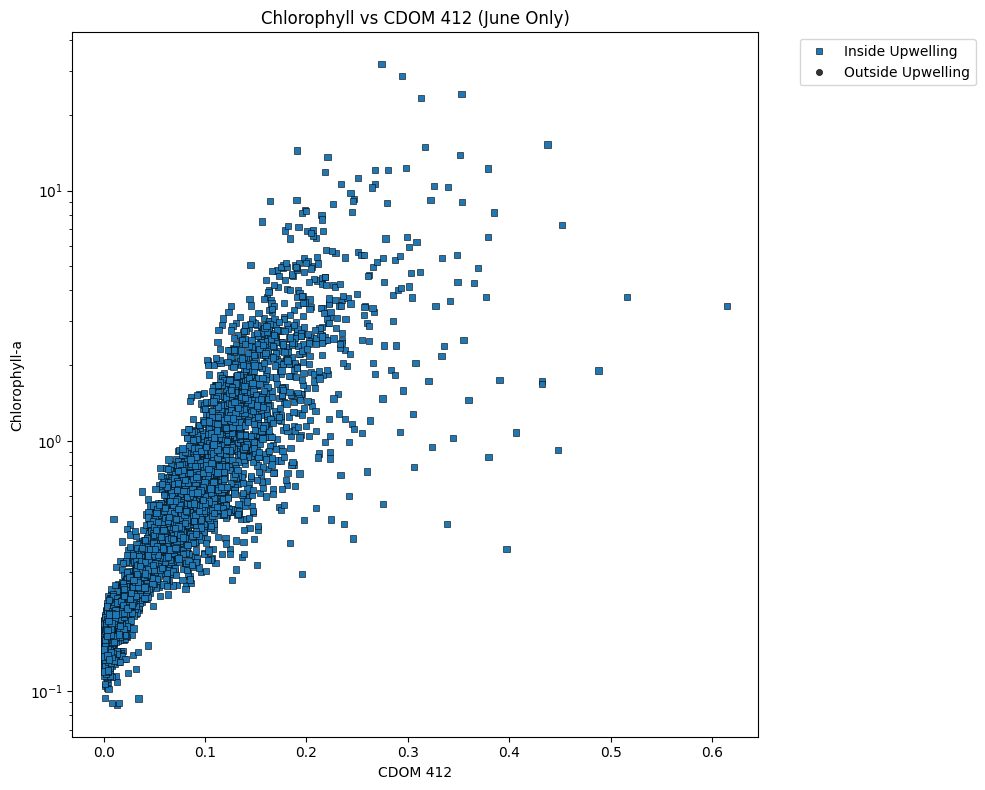

In [17]:
# Create a June-only figure
june_data = sampled_data[sampled_data['month'] == 6].copy()
print(f"June data points: {len(june_data)}")

if june_data.empty:
    print("No June data available after filtering.")
else:
    june_markers = {'Inside Upwelling': 's', 'Outside Upwelling': 'o'}
    june_palette = {'Inside Upwelling': '#1f77b4', 'Outside Upwelling': '#ff7f0e'}

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=june_data,
        x='cdom412',
        y='chlor',
        hue='Zone',
        style='Zone',
        style_order=['Inside Upwelling', 'Outside Upwelling'],
        markers=june_markers,
        palette=june_palette,
        alpha=1,
        s=20,
        edgecolor='black',
        linewidth=0.4
    )

    plt.title('Chlorophyll vs CDOM 412 (June Only)')
    plt.xlabel('CDOM 412')
    plt.ylabel('Chlorophyll-a')
    plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()